In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
# Set matplotlib parameters with a global font size of 7 pt
plt.rcParams.update({
    'font.size': 7,
    'axes.titlesize': 7,
    'axes.labelsize': 7,
    'xtick.labelsize': 7,
    'ytick.labelsize': 7,
    'legend.fontsize': 7,
    'figure.titlesize': 7
})

cm_to_inch = 1 / 2.54
figsize_cm = (9 * cm_to_inch, 9 * cm_to_inch)  # (9cm, 9cm)
fig_size = figsize_cm
fig_args = {"figsize":fig_size}
tick_args = {"pad":0}
lable_args = {"labelpad" : -5}
save_args = {"bbox_inches":'tight', "dpi":300}

In [23]:
def read_csv_as_tuple_list(csv_file):
    df = pd.read_csv(csv_file)
    df = df.astype(object).where(pd.notna(df), None)
    # return list(df.itertuples(index=False, name=None))
    return df

def plot_affinity_bar(df, save_file):   
    molecules = df['Molecule'].unique()
    concentrations = ['20 ng', '100 ng']
    x = np.arange(len(molecules))  # Molecule label positions
    width = 0.35  # Bar width
    
    # Prepare data for each concentration
    means_20ng = []
    stds_20ng = []
    means_100ng = []
    stds_100ng = []
    
    for molecule in molecules:
        # 20 ng data
        data_20 = df[(df['Molecule'] == molecule) & (df['Concentration'] == '20 ng')]
        if len(data_20) > 0:
            means_20ng.append(data_20['Mean'].values[0])
            stds_20ng.append(data_20['Std'].values[0])
        else:
            means_20ng.append(0)
            stds_20ng.append(0)
        
        # 100 ng data
        data_100 = df[(df['Molecule'] == molecule) & (df['Concentration'] == '100 ng')]
        if len(data_100) > 0:
            means_100ng.append(data_100['Mean'].values[0])
            stds_100ng.append(data_100['Std'].values[0])
        else:
            means_100ng.append(0)
            stds_100ng.append(0)
    
    # Keep only bars with data
    molecules_clean = []
    means_20ng_clean = []
    stds_20ng_clean = []
    means_100ng_clean = []
    stds_100ng_clean = []
    
    for i, molecule in enumerate(molecules):
        # Keep molecules with data in either concentration
        if means_20ng[i] > 0 or means_100ng[i] > 0:
            molecules_clean.append(molecule)
            means_20ng_clean.append(means_20ng[i] if means_20ng[i] > 0 else np.nan)
            stds_20ng_clean.append(stds_20ng[i] if means_20ng[i] > 0 else np.nan)
            means_100ng_clean.append(means_100ng[i] if means_100ng[i] > 0 else np.nan)
            stds_100ng_clean.append(stds_100ng[i] if means_100ng[i] > 0 else np.nan)
    
    x_clean = np.arange(len(molecules_clean))
    width = 0.35

    # Set the plotting style
    sns.set_style()
    sns.set_context("paper", font_scale=1)  # font_scale=1 works with the global font.size=7

    fig3, ax3 = plt.subplots(**fig_args)  # Adjust the figure size as needed
    rects2 = ax3.bar(x_clean, means_100ng_clean, width * 2,
                     yerr=stds_100ng_clean,
                     alpha=0.8,
                     edgecolor='black', linewidth=0.5,
                     capsize=3, error_kw={'linewidth': 1, 'ecolor': 'black'},
                     color=custom_colors)
    
    # Set figure properties
    # ax3.set_xlabel('Molecule', fontsize=7)
    ax3.set_ylabel('OD450', fontsize=7)
    # Set a shared range and interval
    y_min = 0
    y_max = 2.5  # Or use the computed y_max
    tick_interval = 0.5
    
    # Generate tick positions
    ticks = np.arange(y_min, y_max + tick_interval, tick_interval)
    
    # Apply to both axes
    ax3.set_yticks(ticks)
    
    # Set the axis range
    ax3.set_ylim(y_min, y_max)

    ax3.tick_params(axis='y', labelsize=7)
    ax3.tick_params(axis='x', labelsize=7)
    
    ax3.set_xticks(x_clean)
    ax3.set_xticklabels(molecules_clean, rotation=45, ha='right', fontsize=7)
    # ax3.legend(fontsize=7, title_fontsize=7, loc='upper right')
    ax3.grid(True,  alpha=0.3, linestyle='--', linewidth=0.5)
    
    plt.savefig(save_file, bbox_inches='tight', dpi=300)
    plt.show()


  Molecule     Mean      Std Concentration
0  Control  2.12235  0.00559        100 ng
1      BSA      0.0      0.0        100 ng
2      PBS      0.0      0.0        100 ng
3     PDN4  0.04145  0.00361        100 ng
4     PDN8  0.11485  0.03118        100 ng
5    PDN12   1.3959  0.10013        100 ng
6    PDN15  2.18705  0.01407        100 ng
7    PDN17   1.8432  0.13364        100 ng
8    PDN19  0.33065  0.05339        100 ng


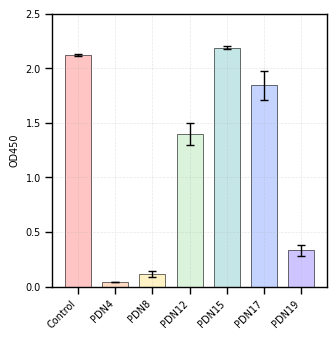

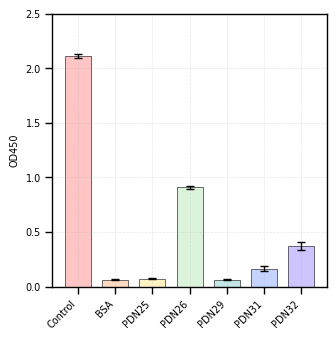

In [22]:
data_100ng_0728 = read_csv_as_tuple_list('data/affinity_100ng_0728.csv')
data_100ng_0821 = read_csv_as_tuple_list('data/affinity_100ng_0821.csv')
print(data_100ng_0728)

custom_colors =[
    '#FFB6B6',
    '#FFD2B6',
    '#FFEFB6',
    '#D1F0D1',
    '#B6E0E0',
    '#B6C9FF',  
    '#C2B6FF',  
    '#E0B6FF'   
]

plot_affinity_bar(data_100ng_0728, 'b0728.svg')
plot_affinity_bar(data_100ng_0821, 'b0821.svg')
